รันโมเดลบนฮาร์ดแวร์: mps

--- Start configuration: LSTM | Frequency 28 GHz | SNR 0 dB ---
Sequence creation complete. LSTM Input shape: (53463, 5, 4096)
Data Split Complete:
 - Training samples: 37424 (First 70%)
 - Testing samples:  16039 (Last 30% - Future Path)
 - SE test shape:    (16039, 64)
Global environment locked with seed: 42
Total Trainable Params: 99414
--> Saved better LSTM model at Epoch 1 with Loss: 2.7559
--> Saved better LSTM model at Epoch 2 with Loss: 1.2405
--> Saved better LSTM model at Epoch 3 with Loss: 0.7291
--> Saved better LSTM model at Epoch 4 with Loss: 0.5095
--> Saved better LSTM model at Epoch 5 with Loss: 0.3966
--> Saved better LSTM model at Epoch 6 with Loss: 0.3262
--> Saved better LSTM model at Epoch 7 with Loss: 0.2804
--> Saved better LSTM model at Epoch 8 with Loss: 0.2513
--> Saved better LSTM model at Epoch 9 with Loss: 0.2285
Epoch [10/100], Avg Loss: 0.2083, LR: 0.001000
--> Saved better LSTM model at Epoch 10 with Loss: 0.2083
--> Saved bett

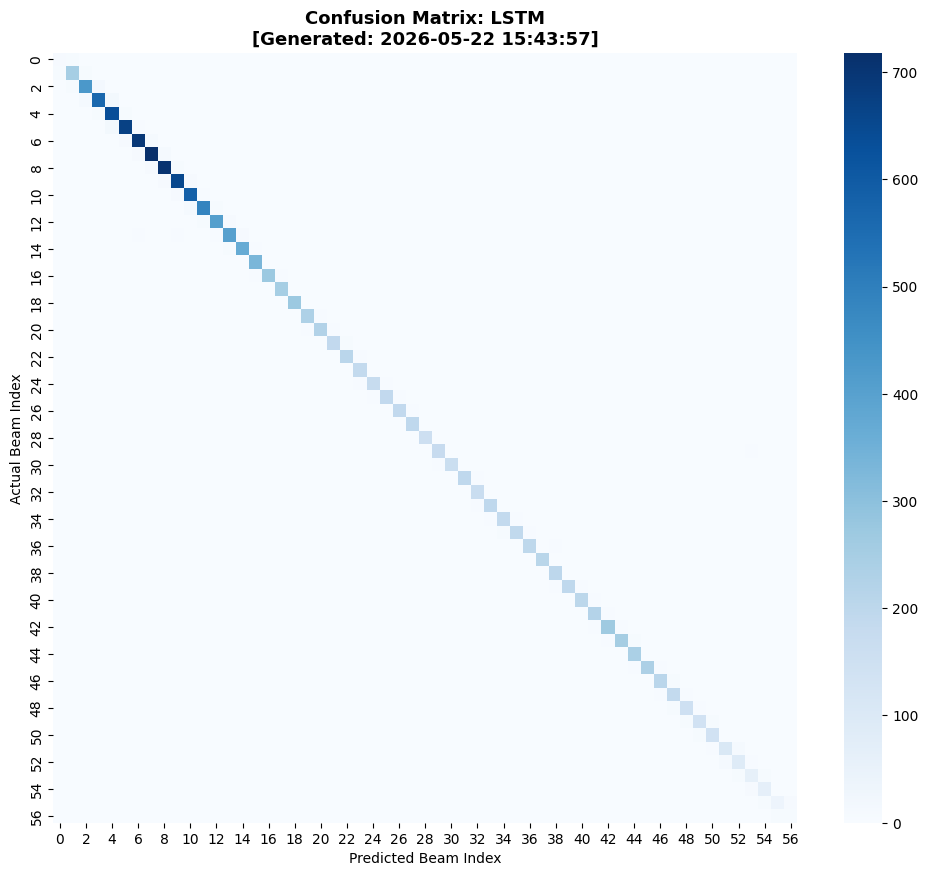

Beam Tracking plot saved as: beam_tracking_lstm_0_O1_28ghz_64ant.png


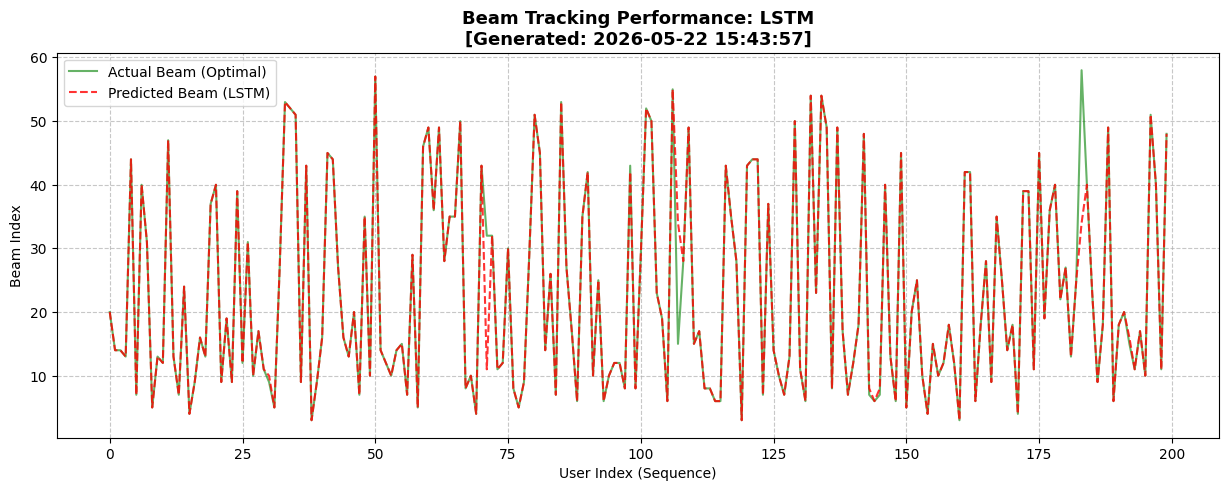

Spectral Efficiency Tracking plot saved as: se_tracking_lstm_0_O1_28ghz_64ant.png


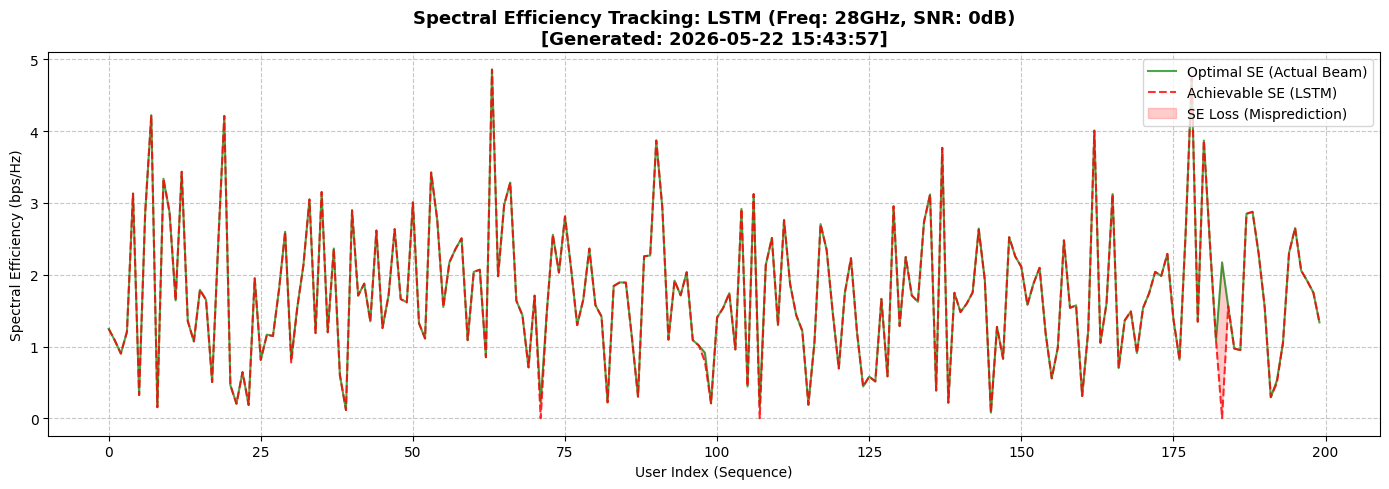

[SUCCESS] Spectral Efficiency report compiled and saved to: ./results/csv/se_summary.csv

--- Start configuration: LSTM | Frequency 60 GHz | SNR 0 dB ---
Sequence creation complete. LSTM Input shape: (53463, 5, 4096)
Data Split Complete:
 - Training samples: 37424 (First 70%)
 - Testing samples:  16039 (Last 30% - Future Path)
 - SE test shape:    (16039, 64)
Global environment locked with seed: 42
Total Trainable Params: 99414
--> Saved better LSTM model at Epoch 1 with Loss: 2.7806
--> Saved better LSTM model at Epoch 2 with Loss: 1.3266
--> Saved better LSTM model at Epoch 3 with Loss: 0.8114
--> Saved better LSTM model at Epoch 4 with Loss: 0.5688
--> Saved better LSTM model at Epoch 5 with Loss: 0.4457
--> Saved better LSTM model at Epoch 6 with Loss: 0.3678
--> Saved better LSTM model at Epoch 7 with Loss: 0.3167
--> Saved better LSTM model at Epoch 8 with Loss: 0.2805
--> Saved better LSTM model at Epoch 9 with Loss: 0.2583
Epoch [10/100], Avg Loss: 0.2442, LR: 0.001000
--> Save

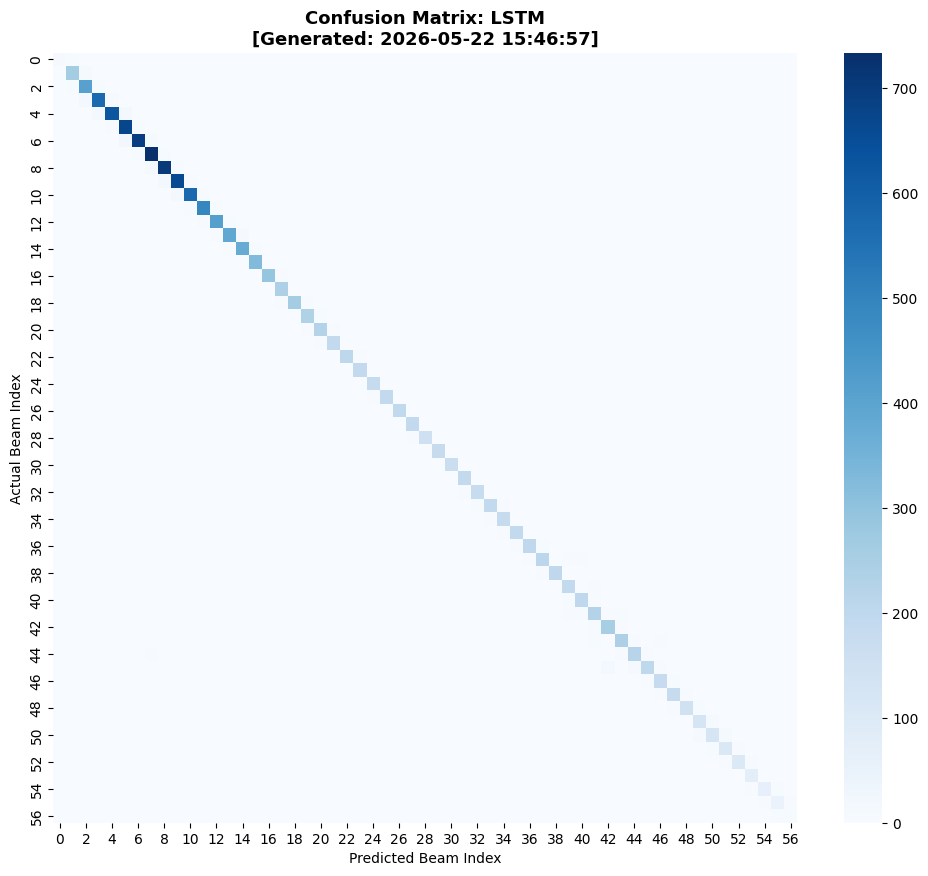

Beam Tracking plot saved as: beam_tracking_lstm_0_O1_60ghz_64ant.png


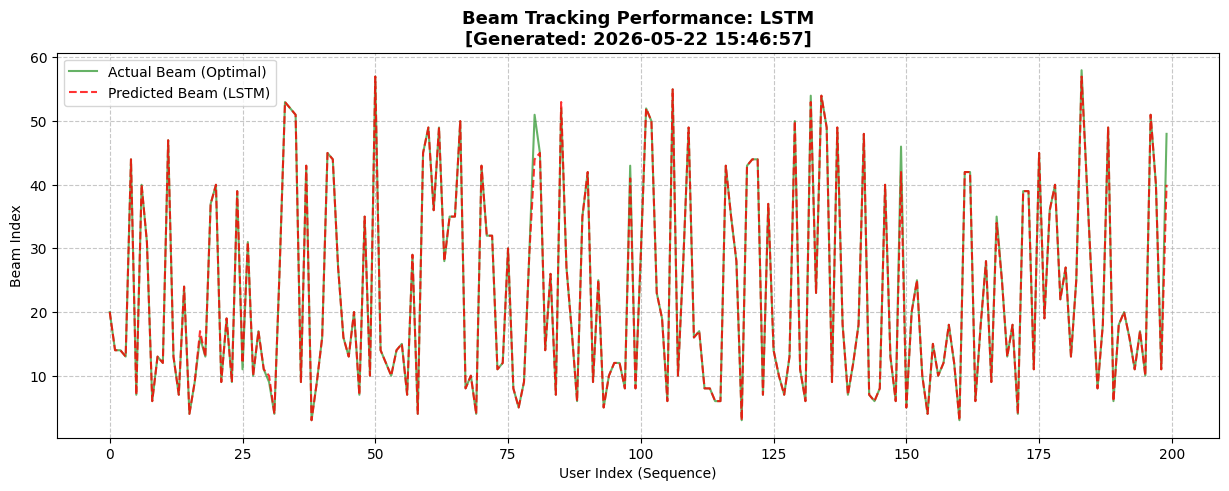

Spectral Efficiency Tracking plot saved as: se_tracking_lstm_0_O1_60ghz_64ant.png


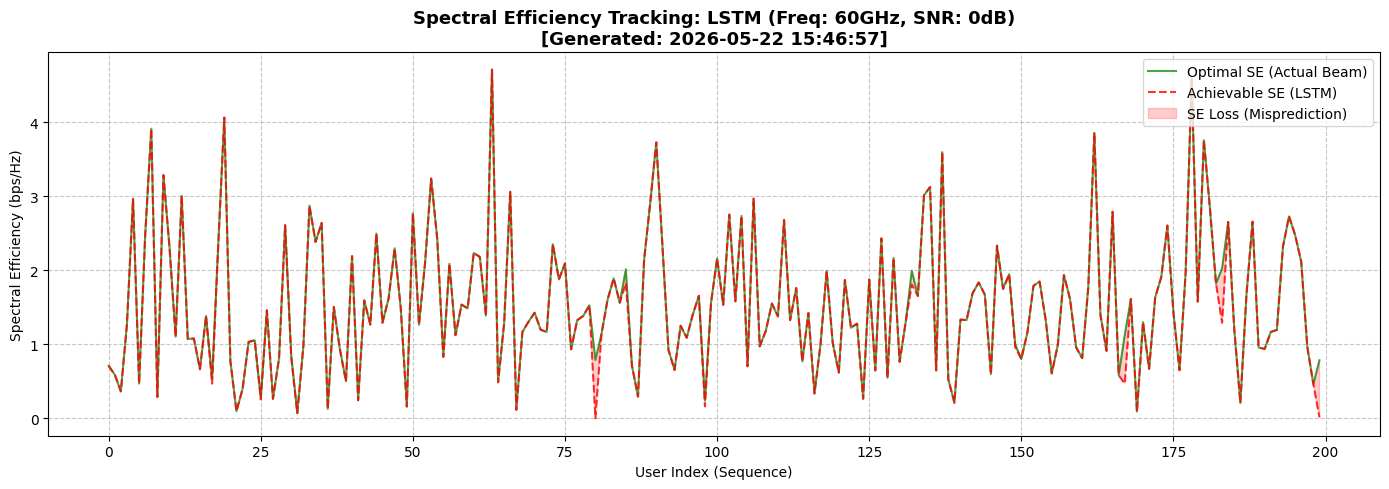

[SUCCESS] Spectral Efficiency report compiled and saved to: ./results/csv/se_summary.csv

--- Start configuration: LSTM | Frequency 140 GHz | SNR 0 dB ---
Sequence creation complete. LSTM Input shape: (53463, 5, 4096)
Data Split Complete:
 - Training samples: 37424 (First 70%)
 - Testing samples:  16039 (Last 30% - Future Path)
 - SE test shape:    (16039, 64)
Global environment locked with seed: 42
Total Trainable Params: 99414
--> Saved better LSTM model at Epoch 1 with Loss: 2.7881
--> Saved better LSTM model at Epoch 2 with Loss: 1.3400
--> Saved better LSTM model at Epoch 3 with Loss: 0.8178
--> Saved better LSTM model at Epoch 4 with Loss: 0.5903
--> Saved better LSTM model at Epoch 5 with Loss: 0.4609
--> Saved better LSTM model at Epoch 6 with Loss: 0.3830
--> Saved better LSTM model at Epoch 7 with Loss: 0.3268
--> Saved better LSTM model at Epoch 8 with Loss: 0.2939
--> Saved better LSTM model at Epoch 9 with Loss: 0.2650
Epoch [10/100], Avg Loss: 0.2437, LR: 0.001000
--> Sav

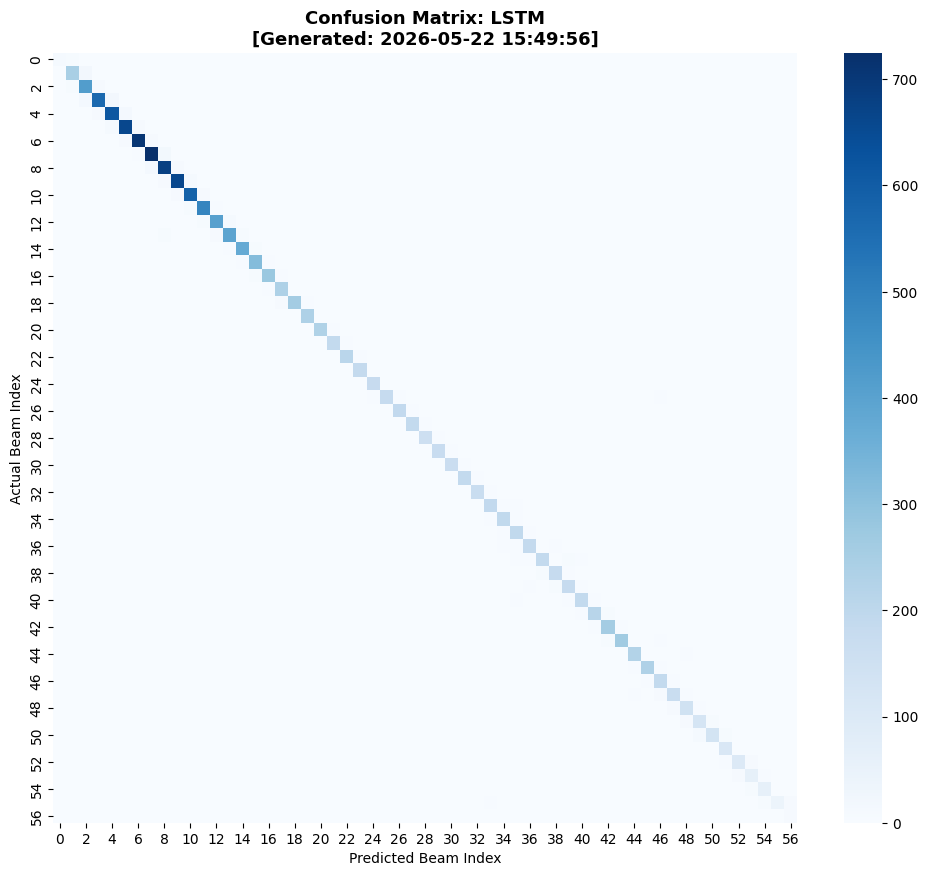

Beam Tracking plot saved as: beam_tracking_lstm_0_O1_140ghz_64ant.png


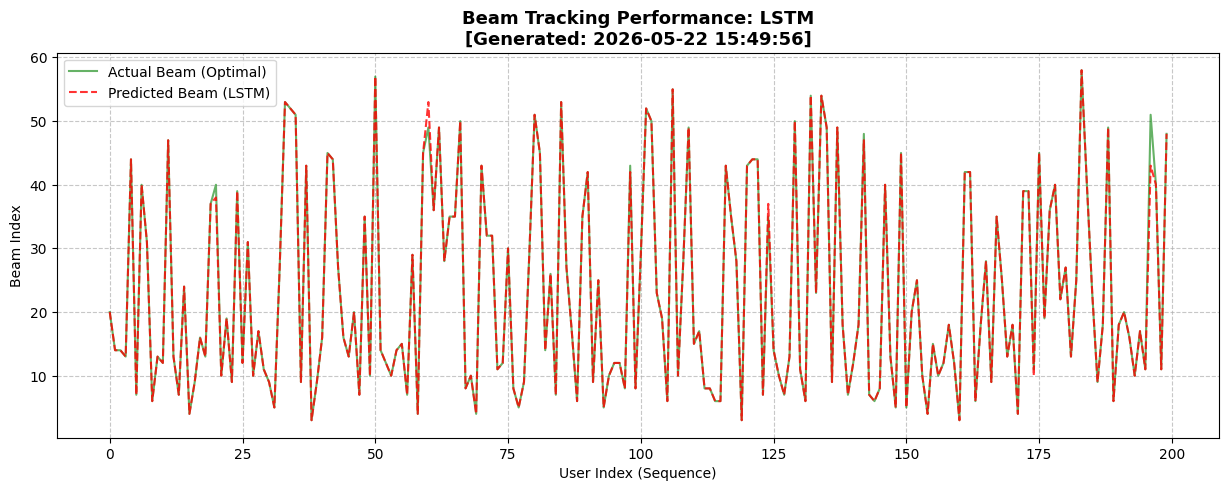

Spectral Efficiency Tracking plot saved as: se_tracking_lstm_0_O1_140ghz_64ant.png


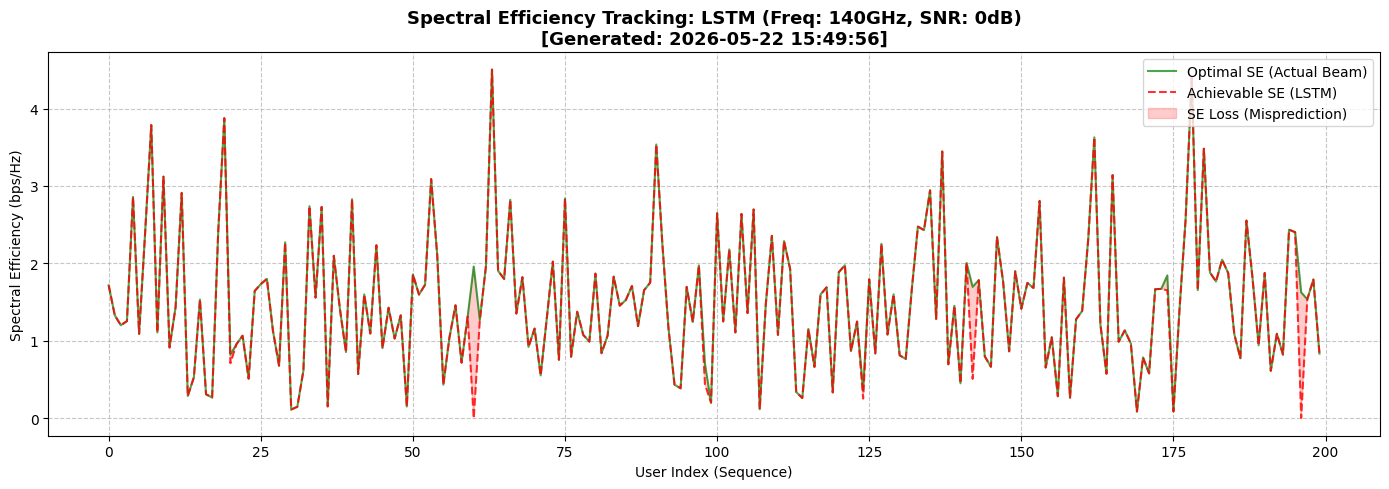

[SUCCESS] Spectral Efficiency report compiled and saved to: ./results/csv/se_summary.csv

=== ALL 3 CONFIGURATIONS FOR LSTM COMPLETE ===


In [2]:
# %% [1. ตรวจสอบสภาพแวดล้อมฮาร์ดแวร์]
import torch

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"รันโมเดลบนฮาร์ดแวร์: {device}")

# %% [2. นำเข้าไลบรารีและตั้งค่าพารามิเตอร์หลักของระบบ Auto ML]
import numpy as np
from scipy.io import loadmat
import torch.nn as nn
import random
import gc
import os
from datetime import datetime as dt
from torch.utils.data import DataLoader, TensorDataset
import evaluate as ev
import visualizer as vis

ai_model = 'lstm'
scenario = 'O1'
antennas = 64
epochs = 100
seq_length = 5
save_path = './best_models/'
os.makedirs(save_path, exist_ok=True)

frequencies = [28, 60, 140]
snr_list = [0]

def apply_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    print(f"Global environment locked with seed: {seed}")

# นิยามสถาปัตยกรรม LSTM
class BeamPredictionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, n_beams, dropout_rate):
        super(BeamPredictionLSTM, self).__init__()
        self.embedding = nn.Linear(input_size, 22)
        lstm_dropout = dropout_rate if num_layers > 1 else 0
        self.lstm = nn.LSTM(22, hidden_size, num_layers, batch_first=True, dropout=lstm_dropout)
        self.fc = nn.Linear(hidden_size, n_beams)

    def forward(self, x):
        x = torch.relu(self.embedding(x))
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# %% [3. เริ่มต้นระบบประมวลผลลูป Auto ML สำหรับ LSTM]
for frequency in frequencies:
    for snr in snr_list:
        print(f"\n" + "="*70)
        print(f"--- Start configuration: LSTM | Frequency {frequency} GHz | SNR {snr} dB ---")
        print("="*70)
        
        # 1. โหลดข้อมูล
        path = f'../DeepMIMO/DeepMIMO/DeepMIMO_dataset/SNR{snr}dB_{scenario}_{frequency}_Ant{antennas}/'
        d1 = loadmat(path+'channel1.mat')['a']
        d2 = loadmat(path+'channel2.mat')['b']
        d3 = loadmat(path+'channel3.mat')['c']

        data = np.concatenate((d1, d2, d3), axis=2).transpose(2, 0, 1)
        del d1, d2, d3

        X_combined = np.concatenate((data.real, data.imag), axis=2).astype(np.float32)
        X_flattened = np.reshape(X_combined, (data.shape[0], -1))
        
        del data, X_combined
        gc.collect()

        # Normalization
        mean = np.mean(X_flattened, axis=0)
        std = np.std(X_flattened, axis=0)
        X_flattened = (X_flattened - mean) / (std + 1e-8)

        # โหลด Label และตาราง SE
        y = loadmat(path + 'DLCB_output.mat')['onehot_label'].astype(np.float32)
        se_data = loadmat(path + 'rate_ave.mat')['DL_output'].astype(np.float32)

        # 2. จัดการข้อมูล Sequence ให้ LSTM และ Map ค่า SE ให้ตรงกัน
        # +1 เพื่อเก็บ Sample สุดท้ายให้ครบ
        num_samples = len(X_flattened) - seq_length + 1 
        
        X_seq = np.zeros((num_samples, seq_length, X_flattened.shape[1]), dtype=np.float32)
        y_seq = np.zeros((num_samples, y.shape[1]), dtype=np.float32)
        se_seq = np.zeros((num_samples, se_data.shape[1]), dtype=np.float32) # อาเรย์รองรับ SE

        for i in range(num_samples):
            X_seq[i] = X_flattened[i : i + seq_length]
            y_seq[i] = y[i + seq_length - 1]
            se_seq[i] = se_data[i + seq_length - 1] # แมป SE ให้ตรงกับ Label

        del X_flattened, y, se_data
        gc.collect()

        print(f"Sequence creation complete. LSTM Input shape: {X_seq.shape}")

        # 3. กระบวนการแบ่งส่วนข้อมูล (70% train, 30% test)
        split_idx = int(len(X_seq) * 0.7)

        X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
        y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]
        
        # ตาราง SE ของ Test Set ที่ถูกจัด Sequence แล้ว
        se_test = se_seq[split_idx:]

        print(f"Data Split Complete:")
        print(f" - Training samples: {len(X_train)} (First 70%)")
        print(f" - Testing samples:  {len(X_test)} (Last 30% - Future Path)")
        print(f" - SE test shape:    {se_test.shape}")

        train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=128, shuffle=True)
        test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=128, shuffle=False)

        # 4. ล็อคความสุ่มและสร้างโมเดล LSTM ใหม่
        apply_global_seed(42)

        model = BeamPredictionLSTM(input_size=4096, hidden_size=32, num_layers=1, n_beams=64, dropout_rate=0.2).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
        criterion = nn.CrossEntropyLoss()

        params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'Total Trainable Params: {params}')

        # 5. ขั้นตอนการเทรน
        best_loss = float('inf')
        train_losses = []

        for epoch in range(epochs):
            epoch_loss = 0.0
            model.train()
            
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, torch.max(labels, 1)[1])
                loss.backward()
                optimizer.step()
                
                epoch_loss += loss.item()
            
            avg_epoch_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_epoch_loss)
                
            scheduler.step(avg_epoch_loss)
                
            if (epoch + 1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Avg Loss: {avg_epoch_loss:.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

            if avg_epoch_loss < best_loss:
                best_loss = avg_epoch_loss
                torch.save(model.state_dict(), save_path+f'best_{ai_model.lower()}_model_snr{snr}_{scenario}_{frequency}ghz_{antennas}ant.pth')
                print(f"--> Saved better LSTM model at Epoch {epoch+1} with Loss: {best_loss:.4f}")

        # 6. ประเมินผลและประมวลภาพสรุปสถิติ (Evaluation & Visualization)
        model.load_state_dict(torch.load(save_path+f'best_{ai_model.lower()}_model_snr{snr}_{scenario}_{frequency}ghz_{antennas}ant.pth'))
        model.eval()

        eval_datetime = dt.now().strftime("%Y-%m-%d %H:%M:%S")

        ds_config = {
            'snr': snr,
            'scenario': scenario,
            'frequency': frequency,
            'antennas': antennas
        }

        mimo_results = ev.evaluate_performance(
            model, test_loader, device, criterion, ai_model, ds_config, eval_datetime)

        vis.plot_confusion_matrix(
            mimo_results['all_actuals'], mimo_results['all_preds'], ai_model, ds_config, eval_datetime)

        vis.plot_beam_tracking(
            mimo_results['all_actuals'], mimo_results['all_preds'], ai_model, ds_config, eval_datetime)

        # 7. แมปข้อมูลเพื่อพล็อต Spectral Efficiency (SE)
        preds_array = np.array(mimo_results['all_preds'])
        actuals_array = np.array(mimo_results['all_actuals'])

        num_users = len(preds_array)
        user_indices = np.arange(num_users)

        predicted_se = se_test[user_indices, preds_array]
        optimal_se = se_test[user_indices, actuals_array]

        plot_limit = 200

        vis.plot_se_tracking(
            user_indices=user_indices[:plot_limit],
            optimal_se=optimal_se[:plot_limit],
            predicted_se=predicted_se[:plot_limit],
            model_name=ai_model,
            ds_config=ds_config,
            eval_datetime=eval_datetime
        )

        # 8. บันทึกผล SE ลงตารางสรุป
        vis.save_se_summary_to_csv(
            mimo_results=mimo_results,
            se_test=se_test,
            model_name=ai_model,
            ds_config=ds_config,
            eval_datetime=eval_datetime
        )
        
        # 9. คืนพื้นที่หน่วยความจำ
        del X_seq, y_seq, se_seq, X_train, X_test, y_train, y_test, se_test
        del train_loader, test_loader, model, optimizer, scheduler, criterion
        gc.collect()
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()

print("\n" + "="*50)
print(f"=== ALL {len(frequencies) * len(snr_list)} CONFIGURATIONS FOR LSTM COMPLETE ===")
print("="*50)